In [1]:
import tensorflow as tf
import numpy as np
import re
import os

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()
    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)

    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor
def retrieve_dict(base_dir, filename):
    # Dictionary to hold costs organized by prefix (i)
    fidelity_dict = {}
    # Iterate through each subfolder in the base directory
    folder_names = os.listdir(base_dir)
    
    # Sort folders numerically or lexicographically
    folder_names.sort(key=lambda x: int(x.split('_')[0]))

    # Iterate through each subfolder in the base directory
    for folder_name_1 in folder_names:
        folder_path = os.path.join(base_dir, folder_name_1)
        if os.path.isdir(folder_path):
            # Extract the prefix for identifying the 'i' value
            prefix = folder_name_1.split('_')[0]
            folder_paths = os.listdir(folder_path)
            directories = [item for item in folder_paths if os.path.isdir(os.path.join(folder_path, item))]
            directories.sort(key=lambda x: float(x.split('_')[-1]))
            for folder_name_2 in directories:
                 
                 folder_path_2 = os.path.join(folder_path, folder_name_2)
                 cost_file_path = os.path.join(folder_path_2, filename)
            
                # Read the cost value from the cost.txt file
                 if os.path.exists(cost_file_path):
                        # Extract the complex number part using regular expression
                        tensor = parse_tensor_from_file(cost_file_path, 1)
                     
                        # Convert the extracted string to a complex number
                        for t in tensor.numpy():
                             # Get the real part and convert to float
                            float_value = 1-t.real
                            # if (float_value < 10e-4): continue
                            if prefix not in fidelity_dict:
                                fidelity_dict[prefix] = []
                            fidelity_dict[prefix].append(abs(float_value))
    
    return fidelity_dict

2025-03-23 13:49:56.758741: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-23 13:49:56.759495: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-23 13:49:56.763324: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-23 13:49:56.793008: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742705396.853845  406475 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742705396.86

W0000 00:00:1742705400.473645  406475 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


{'1': [np.float64(0.0015107091284739527), np.float64(0.009499078761549318), np.float64(0.017689955342269692), np.float64(0.026103989946042905), np.float64(0.034758675442621456), np.float64(0.0436768316804349), np.float64(0.05288778245599535), np.float64(0.06242248067515288), np.float64(0.07232292576995814), np.float64(0.08263579920124842), np.float64(0.09342189213645391), np.float64(0.10475926400009206), np.float64(0.11674920872133476), np.float64(0.12953257654980732), np.float64(0.1433056648545632), np.float64(0.15837397173788081), np.float64(0.17524361036231018), np.float64(0.19488342944618509), np.float64(0.2196985028269437), np.float64(0.2746949025728135)], '2': [np.float64(0.0046728672677107674), np.float64(0.02603194343131876), np.float64(0.04766831070493238), np.float64(0.06962697283958064), np.float64(0.09193938786429123), np.float64(0.11464180062753604), np.float64(0.13777649584752438), np.float64(0.16138784701390296), np.float64(0.18554788817577617), np.float64(0.210328241785

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


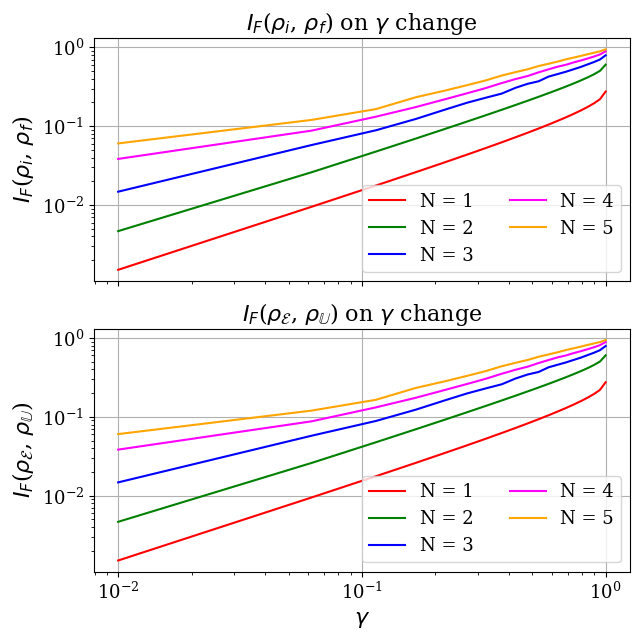

In [2]:
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt

def plot_fidelity(fidelity_dict1, fidelity_dict2, ylabel1, ylabel2, xlabel, xticks, file_name):
    # Set font family to serif
    plt.rc('font', family='serif')
    
    # Create a figure with two subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 6.5), sharex=True)
    colorList = ['r', 'g', 'b', 'magenta', 'orange']
    

    # Plot for the first fidelity dict (Top subplot)
    for i, (key, values) in enumerate(fidelity_dict1.items()):
        ax1.plot(xticks, values, label="N = " + key, color=colorList[i % len(colorList)]) 

    ax1.set_ylabel(ylabel1, fontsize=16)
    ax1.set_title(ylabel1 + ' on ' + xlabel + ' change', fontsize=16)
    ax1.set_yscale('log')  
    ax1.grid(True)
    ax1.legend(fontsize=13, ncol=2)
    
    # Plot for the second fidelity dict (Bottom subplot)
    for i, (key, values) in enumerate(fidelity_dict2.items()):
        ax2.plot(xticks,values, label="N = " + key, color=colorList[i % len(colorList)])  

    ax2.set_xlabel(xlabel, fontsize=16)  
    ax2.set_ylabel(ylabel2, fontsize=16)
    ax2.set_title(ylabel2 + ' on ' + xlabel + ' change', fontsize=16)
    ax2.set_xscale('log')
    ax2.set_yscale('log')  
    ax2.grid(True)

    ax2.legend(fontsize=13, ncol=2)

    ax1.tick_params(axis='y', labelsize=13) 
    ax2.tick_params(axis='y', labelsize=13)

    ax1.tick_params(axis='x', labelsize=13)
    ax2.tick_params(axis='x', labelsize=13)

    # Save the figure
    plt.tight_layout()
    plt.savefig(f'../../docs/new_fig/{file_name}_2.png', format='png')
    plt.savefig(f'../../docs/new_fig/{file_name}_2.eps', format='eps')

    # Display the plot
    plt.show()

xticks = np.linspace(10e-3, 1, 20)
fidelity_dict_rho_rho3 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho_rho3_test.txt')
print(fidelity_dict_rho_rho3)
fidelity_dict_rho2_rho2 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho2_rho2_test.txt')
plot_fidelity(fidelity_dict_rho_rho3, fidelity_dict_rho2_rho2, "$I_F$($\\rho_i$, $ \\rho_f$)", "$I_F$($\\rho_\\mathcal{E}$, $\\rho_\\mathbb{U}$)", '$\\gamma$', xticks, 'fidelity_rho-rho3_rho-rho2_2')